In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets, layers ,models
import matplotlib.pyplot as plt

%matplotlib inline

In [3]:
(x_train,y_train),(x_test,y_test)=keras.datasets.mnist.load_data()

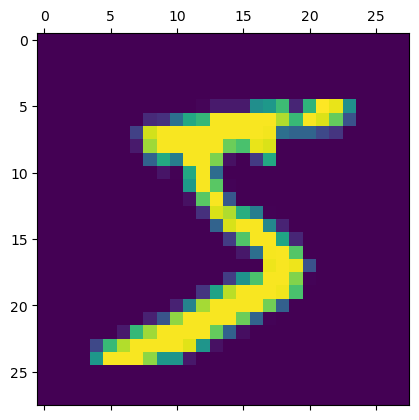

In [4]:
plt.matshow(x_train[0])

In [5]:
y_train[1]

0

In [6]:
x_train=x_train/255

In [7]:
x_test=x_test/255

In [8]:
x_train_flattened=x_train.reshape(len(x_train),28*28)

In [9]:
x_test_flattened=x_test.reshape(len(x_test),28*28)

In [10]:
x_train_flattened.shape

(60000, 784)

In [11]:
model=keras.Sequential([
    keras.layers.Dense(100,input_shape=(784,),activation='relu'),
    keras.layers.Dense(10,activation='sigmoid')
])
model.compile(optimizer='adam', loss='SparseCategoricalCrossentropy',metrics=['accuracy'])


In [12]:
model.fit(x_train_flattened,y_train,epochs=5)

Epoch 1/5
1875/1875 [==============================] - 6s 3ms/step - loss: 0.2769 - accuracy: 0.9215
Epoch 2/5
1875/1875 [==============================] - 5s 3ms/step - loss: 0.1241 - accuracy: 0.9638
Epoch 3/5
1875/1875 [==============================] - 5s 3ms/step - loss: 0.0862 - accuracy: 0.9742
Epoch 4/5
1875/1875 [==============================] - 5s 3ms/step - loss: 0.0670 - accuracy: 0.9793
Epoch 5/5
1875/1875 [==============================] - 5s 3ms/step - loss: 0.0529 - accuracy: 0.9837


In [13]:
model.evaluate(x_test_flattened,y_test)

313/313 [==============================] - 1s 2ms/step - loss: 0.0862 - accuracy: 0.9758


[0.08621332049369812, 0.9757999777793884]

In [14]:
y_predicted=model.predict(x_test_flattened)

313/313 [==============================] - 1s 2ms/step


In [15]:
np.argmax(y_predicted[1])

2

In [16]:
y_pred_lab=[np.argmax(i) for i in y_predicted]

In [17]:
y_pred_lab[:10]

[7, 2, 1, 0, 4, 1, 4, 9, 6, 9]

In [18]:
y_test[:10]

array([7, 2, 1, 0, 4, 1, 4, 9, 5, 9], dtype=uint8)

In [19]:
cm=tf.math.confusion_matrix(labels=y_test,predictions=y_pred_lab)

<AxesSubplot:>

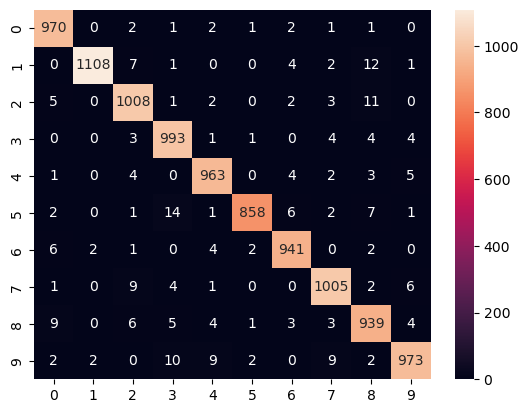

In [20]:
sns.heatmap(cm,annot=True,fmt='d')

In [26]:
cnn=models.Sequential([
    layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(filters=64,kernel_size=(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(10,activation='softmax')
])

In [29]:
cnn.compile(optimizer='adam',
           loss='SparseCategoricalCrossentropy',
           metrics=['accuracy'])

In [30]:
cnn.fit(x_train,y_train,epochs=100)

Epoch 1/100
1875/1875 [==============================] - 47s 25ms/step - loss: 0.1522 - accuracy: 0.9540
Epoch 2/100
1875/1875 [==============================] - 45s 24ms/step - loss: 0.0478 - accuracy: 0.9853
Epoch 3/100
1875/1875 [==============================] - 44s 24ms/step - loss: 0.0339 - accuracy: 0.9894
Epoch 4/100
1875/1875 [==============================] - 62s 33ms/step - loss: 0.0246 - accuracy: 0.9922
Epoch 5/100
1875/1875 [==============================] - 69s 37ms/step - loss: 0.0191 - accuracy: 0.9939
Epoch 6/100
1875/1875 [==============================] - 81s 43ms/step - loss: 0.0143 - accuracy: 0.9954
Epoch 7/100
1875/1875 [==============================] - 81s 43ms/step - loss: 0.0118 - accuracy: 0.9961
Epoch 8/100
1875/1875 [==============================] - 80s 43ms/step - loss: 0.0101 - accuracy: 0.9967
Epoch 9/100
1875/1875 [==============================] - 79s 42ms/step - loss: 0.0083 - accuracy: 0.9974
Epoch 10/100
1875/1875 [==============================]

In [31]:
cnn.evaluate(x_test,y_test)

313/313 [==============================] - 5s 15ms/step - loss: 0.1538 - accuracy: 0.9928


[0.15384705364704132, 0.9927999973297119]

In [33]:
y_predi=cnn.predict(x_test)

313/313 [==============================] - 4s 13ms/step


In [34]:
y_pred=[np.argmax(i) for i in y_predi]

In [36]:
y_pred[:5]

[7, 2, 1, 0, 4]

In [37]:
y_test[:5]

array([7, 2, 1, 0, 4], dtype=uint8)

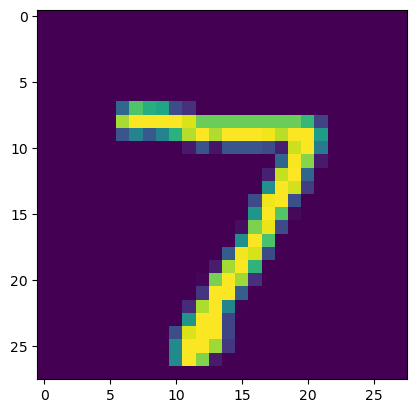

In [39]:
plt.imshow(x_test[0])

In [40]:
from sklearn.metrics import confusion_matrix, classification_report

In [41]:
cm=confusion_matrix(y_test,y_pred)

<AxesSubplot:>

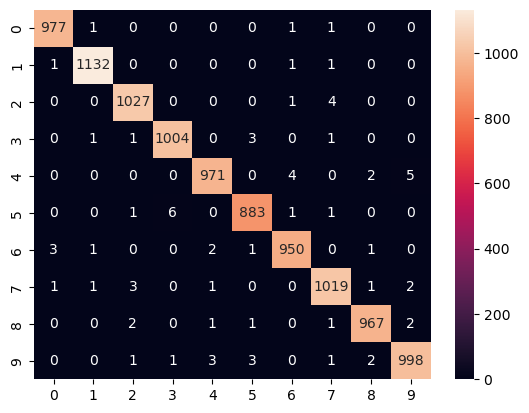

In [42]:
sns.heatmap(cm, annot=True,fmt='d')

In [43]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       0.99      1.00      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

